**Table of contents**<a id='toc0_'></a>    
- [Data Cleaning and Pre-Processing](#toc1_)    
  - [Loading Datasets](#toc1_1_)    
  - [Cleaning Individual Tables](#toc1_2_)    
    - [GC Cleaning (masterdatagcs)](#toc1_2_1_)    
  - [Table I: Create gcs_unique Table](#toc1_3_)    
  - [Table II: Create gcs_detailed Table](#toc1_4_)    
    - [Clients Cleaning (masterdataclients_...)](#toc1_4_1_)    
      - [Cleaning Age](#toc1_4_1_1_)    
      - [Other metrics](#toc1_4_1_2_)    
      - [Call Count by Issue](#toc1_4_1_3_)    
- [Prop OTS](#toc2_)    
- [Fill with 0](#toc3_)    
    - [Call Data Cleaning (mastercalls_xxx_yyy)](#toc3_1_1_)    
  - [Merging Datasets](#toc3_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Data Cleaning and Pre-Processing](#toc0_)

## <a id='toc1_1_'></a>[Loading Datasets](#toc0_)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import getpass
import dask.dataframe as dd

In [2]:
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)  # Avoid truncation of wide output
pd.set_option('display.max_colwidth', None)  # Avoid truncation of column content

In [3]:
# Connection details
host = "172.20.20.4"
port = "5432"
database = "nos"
user = "dvolin"
password = 'AR4R11SErro='

In [4]:
# Create a SQLAlchemy engine
engine = create_engine(f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}')

list_1 = [
    'masterdataclients_jan_may',
    'masterdataclients_jun_oct',
    'mastercalls_jan_feb',
    'mastercalls_mar_apr',
    'mastercalls_may_jul',
    'mastercalls_aug_oct',
    'masterdatagcs'
    ]
# Function to fetch data from a specific table
def fetch_table(table_name):
    query = f"SELECT * FROM nos2425.{table_name}  ;"
    return pd.read_sql_query(query, engine)

# Loop through the list, fetch each table, and assign it to a variable with the table name
for table_name in list_1:
    df = fetch_table(table_name)  # Fetch the table data
    
    # Dynamically create a variable with the table name to store the data
    globals()[table_name] = df
    

In [5]:
clients_df = pd.concat([masterdataclients_jan_may, masterdataclients_jun_oct], ignore_index=True)
calls_df = pd.concat([mastercalls_jan_feb, mastercalls_mar_apr, mastercalls_may_jul, mastercalls_aug_oct], ignore_index=True)


In [7]:
calls_df.head()

,Column1,LEG_IF_ID,PERSON_ID,PERSON_SK,CALL_IF_ID,GROUP_KEY,RESOURCE_KEY,NR_RPC_0,NR_RPC_1,NR_INCIDENTS_PER_LEG,CALL_START_TIME_DAT,CALL_END_TIME_DAT,LEG_START_TIME_DAT,LEG_END_TIME_DAT,LEG_DURATION_SEC_QTY,CALL_DURATION_SEQ_QTY,TOPIC_TIPIFICATION_LVL_1_DSC,TOPIC_TIPIFICATION_LVL_2_DSC,TOPIC_TIPIFICATION_LVL_3_DSC,TOPIC_CLASSIFIC_ENTRY_AT_FT,WORK_ORDER_ID,TIBCO_DIFFUSION_DAT,TOPIC_INCIDENT_COD_COUNT,FTR_1_SUM,FTR_CALCULATED,WORK_ORDER_SCHEDULE_END_DAT,FLAG_OT
0,0,8603977337,0VSSAR8xznOwGntjNuVUVgvyXR0Enr1mDNgv+yLTxcw4=,02M8ZBia+nxzPglxqSo/EdL3CorWy2fd1q+AxZtkGnq0=,1755663045,588010001,13390500002,0.0,0.0,1.0,2024-02-26 17:08:40.000,2024-02-26 17:14:38.000,2024-02-26 17:09:02,2024-02-26 17:14:38,337,358,,,,OTHER,,,NaN,NaN,NaN,,0
1,1,8465942989,0ou2rrL13pM8c5nZAExChfwGexuEwslrMJLDL4jHc6KA=,0ntCebaXuQNnzplBTppXC6H5rTyb5ZOaEqQjmRuYSNZ4=,1732045213,515960193,12060520043,0.0,1.0,1.0,2024-01-02 16:24:54.000,2024-01-02 16:34:10.000,2024-01-02 16:28:08,2024-01-02 16:34:10,362,556,FATURA,TIPO DE FATURA,EU QUERO ALTERAR O TIPO DE FATURA ELETRÓNICA/PAPEL,OTHER,,,1.0,0.0,0.0,,0
2,2,8529228269,0ou2rrL13pM8c5nZAExChfwGexuEwslrMJLDL4jHc6KA=,0ntCebaXuQNnzplBTppXC6H5rTyb5ZOaEqQjmRuYSNZ4=,1742839855,633770001,14420930001,0.0,1.0,1.0,2024-01-27 11:49:10.000,2024-01-27 11:55:19.000,2024-01-27 11:51:39,2024-01-27 11:55:19,221,369,PRODUTOS E SERVIÇOS,CANCELAMENTO,EU QUERO CANCELAR O SERVIÇO,OTHER,,,1.0,0.0,0.0,,0
3,3,8573792421,0nc1/g/XR1O61nzkU+VWFRoJfoiKKZcT8V83xV3SEOOU=,0/dQIFerEMS6cXrSxVD6H67/4mpxBvD0W8PBnWLHd8IE=,1750449197,601030001,13412330001,0.0,1.0,1.0,2024-02-14 13:07:35.000,2024-02-14 13:16:50.000,2024-02-14 13:10:56,2024-02-14 13:16:50,354,555,FATURA,ACORDO DE PAGAMENTO,EU QUERO FAZER UM ACORDO DE PAGAMENTO,OTHER,,,1.0,0.0,0.0,,0
4,4,8537324365,0EFrU58VCV1imPbksFIw2WXL1aZXFS3IR19ONzWoFK5o=,0GpkeP/w44yaasT+pWVYKxx18fsXnft+fkRT341yHZ6U=,1744183583,543520060,11758190031,NaN,NaN,NaN,2024-01-31 09:12:00.000,2024-01-31 09:20:32.000,2024-01-31 09:12:13,2024-01-31 09:20:32,499,512,,,,OTHER,,,NaN,NaN,NaN,,0


In [11]:
# Add a new column 'FTR_depen' to the calls_df DataFrame which if FTR_1_SUM > 1, then 1 else 0
calls_df['FTR_depen'] = np.where(calls_df['FTR_1_SUM'] > 1, 1, 0)

C:\Users\danie\AppData\Local\Temp\ipykernel_8184\2543711351.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=calls_df, x='FTR_depen', palette='viridis')


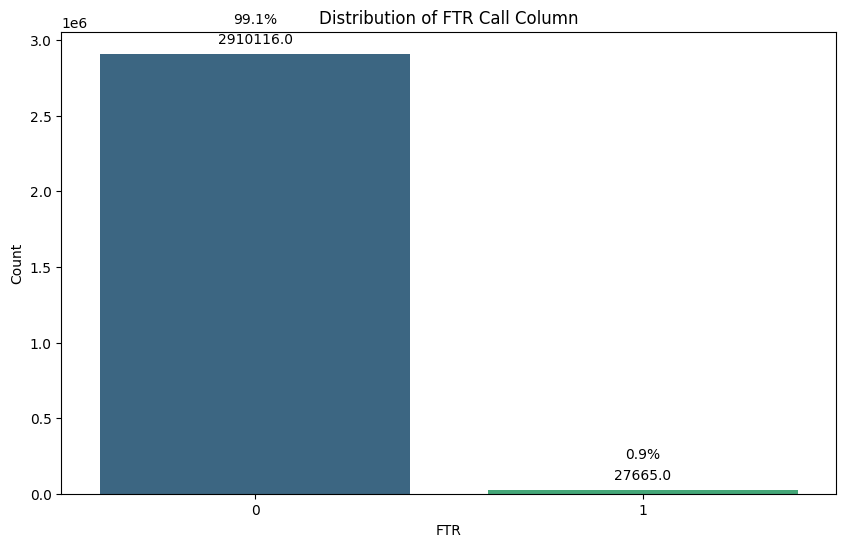

In [12]:
# Plot a bar chart distribution of the FTR_depen call column
plt.figure(figsize=(10, 6))
sns.countplot(data=calls_df, x='FTR_depen', palette='viridis')
plt.title('Distribution of FTR Call Column')
plt.xlabel('FTR')
plt.ylabel('Count')
# add numbers an percentages on top of the bars
for p in plt.gca().patches:
    plt.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                 textcoords='offset points')
    total = len(calls_df)
    percentage = f'{100 * p.get_height() / total:.1f}%'
    plt.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 20),
                 textcoords='offset points')


C:\Users\danie\AppData\Local\Temp\ipykernel_8184\3387731758.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=calls_df, x='FLAG_OT', palette='viridis')


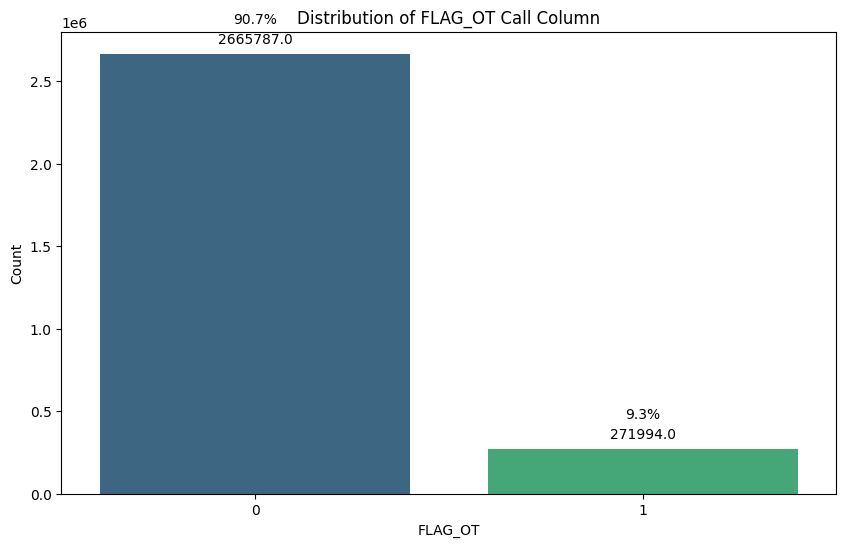

In [10]:
# Plot a bar chart distribution of the FLAG_OT call column
plt.figure(figsize=(10, 6))
sns.countplot(data=calls_df, x='FLAG_OT', palette='viridis')
plt.title('Distribution of FLAG_OT Call Column')
plt.xlabel('FLAG_OT')
plt.ylabel('Count')
# add numbers an percentages on top of the bars
for p in plt.gca().patches:
    plt.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                 textcoords='offset points')
    total = len(calls_df)
    percentage = f'{100 * p.get_height() / total:.1f}%'
    plt.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 20),
                 textcoords='offset points')


In [13]:
df = pd.read_csv(r'full_merged_df.csv')


KeyboardInterrupt



In [14]:
call_df_dropped = calls_df.dropna()

C:\Users\danie\AppData\Local\Temp\ipykernel_8184\2892842677.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=call_df_dropped, x='FTR_depen', palette='viridis')


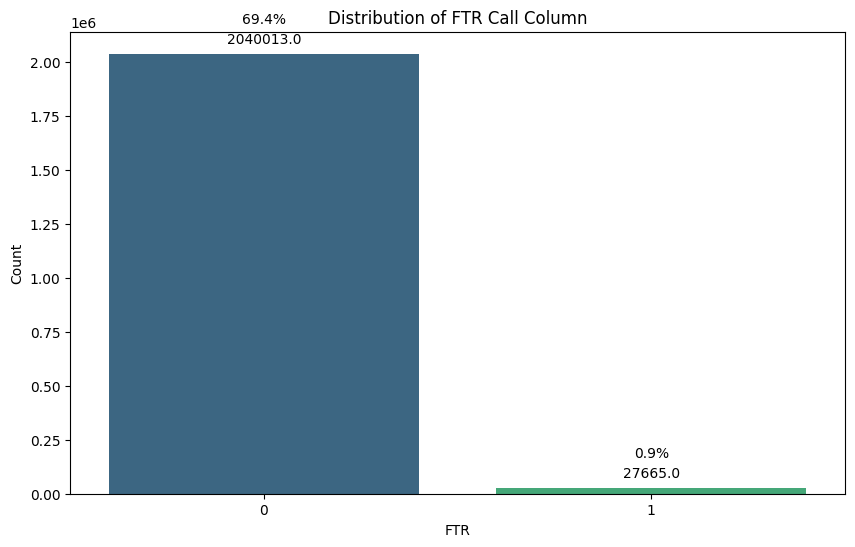

In [16]:
# Plot a bar chart distribution of the FTR_depen call column
plt.figure(figsize=(10, 6))
sns.countplot(data=call_df_dropped, x='FTR_depen', palette='viridis')
plt.title('Distribution of FTR Call Column')
plt.xlabel('FTR')
plt.ylabel('Count')
# add numbers an percentages on top of the bars
for p in plt.gca().patches:
    plt.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                 textcoords='offset points')
    total = len(calls_df)
    percentage = f'{100 * p.get_height() / total:.1f}%'
    plt.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 20),
                 textcoords='offset points')


C:\Users\danie\AppData\Local\Temp\ipykernel_8184\3869767253.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=call_df_dropped, x='FLAG_OT', palette='viridis')


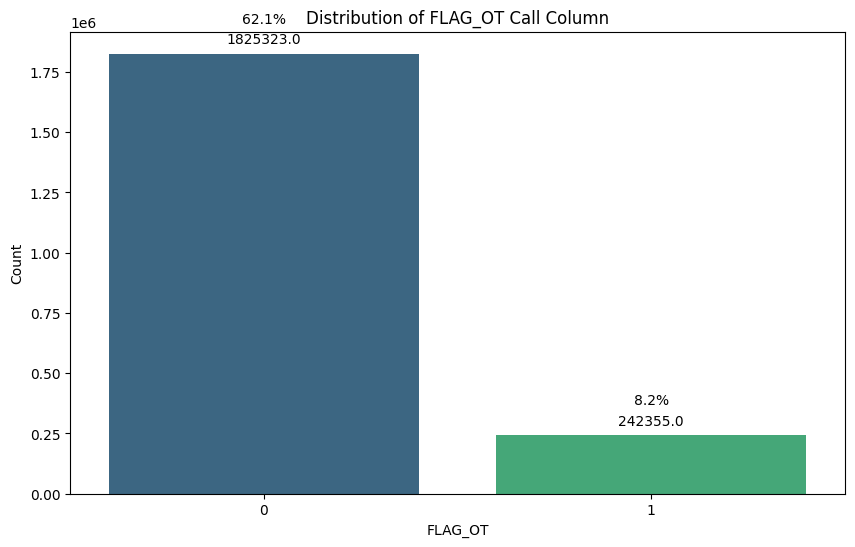

In [17]:
# Plot a bar chart distribution of the FLAG_OT call column
plt.figure(figsize=(10, 6))
sns.countplot(data=call_df_dropped, x='FLAG_OT', palette='viridis')
plt.title('Distribution of FLAG_OT Call Column')
plt.xlabel('FLAG_OT')
plt.ylabel('Count')
# add numbers an percentages on top of the bars
for p in plt.gca().patches:
    plt.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                 textcoords='offset points')
    total = len(calls_df)
    percentage = f'{100 * p.get_height() / total:.1f}%'
    plt.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 20),
                 textcoords='offset points')


## <a id='toc1_2_'></a>[Cleaning Individual Tables](#toc0_)

### <a id='toc1_2_1_'></a>[GC Cleaning (masterdatagcs)](#toc0_)

In [ ]:
# GC Cleaning

# Step 1: Start from original masterdatagcs
masterdatagcs_filtered = masterdatagcs.copy()

# Step 2: Remove columns with 'MEDIAN' in the name
columns_to_keep = [col for col in masterdatagcs_filtered.columns if 'MEDIAN' not in col]
masterdatagcs_filtered = masterdatagcs_filtered[columns_to_keep]

# Step 3: Drop irrelevant column RESOURCE_ID
if 'RESOURCE_ID' in masterdatagcs_filtered.columns:
    masterdatagcs_filtered = masterdatagcs_filtered.drop(columns=['RESOURCE_ID'])

# Step 4: Revert FTR values (FTR = 1 - FTR)
ftr_columns = [col for col in masterdatagcs_filtered.columns if 'FTR' in col]
for col in ftr_columns:
    masterdatagcs_filtered[col] = 1 - masterdatagcs_filtered[col]

# Remove index
masterdatagcs_filtered = masterdatagcs_filtered.reset_index(drop=True)

# Display the cleaned dataset
masterdatagcs_filtered.head()

In [ ]:
# Count NaNs in each column
na_counts = masterdatagcs_filtered.isna().sum()

# Display only columns with at least one NaN
na_counts = na_counts[na_counts > 0]
print(na_counts)

## <a id='toc1_3_'></a>[Table I: Create gcs_unique Table](#toc0_)
The output of this cleaning is the gcs_unique table which contains one row per GC, representing their overall performance. It includes key metrics like FTR, TMC, and call counts across categories.

In [ ]:
# Ensure LEG_START_TIME is datetime and extract date part
masterdatagcs_filtered['LEG_START_TIME'] = pd.to_datetime(masterdatagcs_filtered['LEG_START_TIME'])
masterdatagcs_filtered['LEG_START_DATE'] = masterdatagcs_filtered['LEG_START_TIME'].dt.date

# Calculate DAYS_ACTIVE per RESOURCE_KEY
masterdatagcs_filtered['DAYS_ACTIVE'] = masterdatagcs_filtered.groupby('RESOURCE_KEY')['LEG_START_DATE'].transform('nunique')

# Define the columns to keep (exclude LEG_START_TIME)
columns_to_keep = [
    "RESOURCE_KEY", "COUNT_CALLS", "DAYS_ACTIVE",
    "MEAN_RPC", "MEAN_FTR", "MEAN_TMC", "TOTAL_OTS", "OTS_BY_CALL",
    "COUNT_CALLS_IF", "MEAN_RPC_IF", "MEAN_FTR_IF", "MEAN_TMC_IF", "TOTAL_OTS_IF", "OTS_BY_CALL_IF",
    "COUNT_CALLS_OTHER", "MEAN_RPC_OTHER", "MEAN_FTR_OTHER", "MEAN_TMC_OTHER", "TOTAL_OTS_OTHER", "OTS_BY_CALL_OTHER",
    "COUNT_CALLS_VF", "MEAN_RPC_VF", "MEAN_FTR_VF", "MEAN_TMC_VF", "TOTAL_OTS_VF", "OTS_BY_CALL_VF",
    "COUNT_CALLS_TV", "MEAN_RPC_TV", "MEAN_FTR_TV", "MEAN_TMC_TV", "TOTAL_OTS_TV", "OTS_BY_CALL_TV",
    "COUNT_CALLS_MOVEL", "MEAN_RPC_MOVEL", "MEAN_FTR_MOVEL", "MEAN_TMC_MOVEL", "TOTAL_OTS_MOVEL", "OTS_BY_CALL_MOVEL"
]

# Sort and select most recent entry per RESOURCE_KEY, then keep only desired columns
#gcs_unique = (
#    masterdatagcs_filtered.sort_values(["RESOURCE_KEY", "LEG_START_TIME"], ascending=[True, False])
#    .drop_duplicates(subset="RESOURCE_KEY", keep="first")[columns_to_keep]
#)


# Drop RESOURCE_KEY from columns_to_keep if it's there
columns_to_keep_no_key = [col for col in columns_to_keep if col != "RESOURCE_KEY"]

def mode_agg(group):
    return group.mode().iloc[0] if not group.mode().empty else group.iloc[0]

# Group and aggregate
gcs_unique = (
    masterdatagcs_filtered
    .groupby("RESOURCE_KEY")[columns_to_keep_no_key]
    .agg(mode_agg)
    .reset_index()  # now this works safely — RESOURCE_KEY comes back as a column
)

# Remove index
#gcs_unique = gcs_unique.reset_index(drop=True)

# Output shape and preview
print("Shape of the resulting DataFrame:", gcs_unique.shape)

gcs_unique.head()

In [ ]:
# Define columns grouped by category
category_columns = {
    "IF": ["COUNT_CALLS_IF", "MEAN_RPC_IF", "MEAN_FTR_IF", "MEAN_TMC_IF", "TOTAL_OTS_IF", "OTS_BY_CALL_IF"],
    "OTHER": ["COUNT_CALLS_OTHER", "MEAN_RPC_OTHER", "MEAN_FTR_OTHER", "MEAN_TMC_OTHER", "TOTAL_OTS_OTHER", "OTS_BY_CALL_OTHER"],
    "VF": ["COUNT_CALLS_VF", "MEAN_RPC_VF", "MEAN_FTR_VF", "MEAN_TMC_VF", "TOTAL_OTS_VF", "OTS_BY_CALL_VF"],
    "TV": ["COUNT_CALLS_TV", "MEAN_RPC_TV", "MEAN_FTR_TV", "MEAN_TMC_TV", "TOTAL_OTS_TV", "OTS_BY_CALL_TV"],
    "MOVEL": ["COUNT_CALLS_MOVEL", "MEAN_RPC_MOVEL", "MEAN_FTR_MOVEL", "MEAN_TMC_MOVEL", "TOTAL_OTS_MOVEL", "OTS_BY_CALL_MOVEL"]
}

# Loop over each category and create binary flags, then fill NaNs with 0
for cat, cols in category_columns.items():
    # Create binary column: 0 if all values in category are NaN, 1 otherwise
    gcs_unique[f"CALLS_{cat}_BINARY"] = gcs_unique[cols].notna().any(axis=1).astype(int)
    
# Replace all NaNs in the DataFrame with 0
gcs_unique = gcs_unique.fillna(0)

# Optional: check if any NaNs remain
print("Remaining NaNs:\n", gcs_unique.isna().sum()[gcs_unique.isna().sum() > 0])

In [ ]:
# Count NaNs per column in gcs_unique
na_counts = gcs_unique.isna().sum()
na_counts = na_counts[na_counts > 0]  # Show only columns with at least one NaN
na_counts

In [ ]:
# Count number of zeros in each column of gcs_unique
zero_counts = (gcs_unique == 0).sum()
zero_counts = zero_counts[zero_counts > 0]  # Show only columns with at least one zero
zero_counts

In [ ]:
# Save gcs_unique as a CSV in the working directory
gcs_unique.to_csv("gcs_unique.csv", index=False)

## <a id='toc1_4_'></a>[Table II: Create gcs_detailed Table](#toc0_)
The output of this cleaning is the gcs_unique table which contains one row per GC per day, representing their performance including a temporal component. It includes key metrics like FTR, TMC, and call counts across categories. It also contains detailed information about the performance and call counts per category for the past 14 and 30 days going back from the corresponding day.

In [ ]:
# Copy the original DataFrame
gcs_detailed = masterdatagcs_filtered.copy()

# Columns for which we want to create binary flags
cols_to_check = [
    "COUNT_LEGS_IF_14_DAYS", "COUNT_LEGS_MOVEL_14_DAYS",
    "COUNT_LEGS_TV_14_DAYS", "COUNT_LEGS_VF_14_DAYS",
    "COUNT_LEGS_IF_30_DAYS", "COUNT_LEGS_MOVEL_30_DAYS",
    "COUNT_LEGS_TV_30_DAYS", "COUNT_LEGS_VF_30_DAYS"
]

# Add binary columns: 0 if NaN, 1 otherwise
for col in cols_to_check:
    binary_col = f"{col}_BINARY"
    gcs_detailed[binary_col] = gcs_detailed[col].notna().astype(int)

# Drop LEG_START_DATE and DAYS_ACTIVE from gcs_detailed
gcs_detailed = gcs_detailed.drop(columns=["LEG_START_DATE", "DAYS_ACTIVE","Column1"])

# Replace all NaNs with 0 in the new DataFrame
gcs_detailed = gcs_detailed.fillna(0)
gcs_detailed.head()

In [ ]:
# Count NaNs per column in gcs_unique
na_counts = gcs_detailed.isna().sum()
na_counts = na_counts[na_counts > 0]  # Show only columns with at least one NaN
na_counts

In [ ]:
# Save gcs_detailed as a CSV in the working directory
gcs_detailed.to_csv("gcs_detailed.csv", index=False)

### <a id='toc1_4_1_'></a>[Clients Cleaning (masterdataclients_...)](#toc0_)

In [ ]:
# Client Cleaning 
client_df = pd.concat([masterdataclients_jan_may, masterdataclients_jun_oct], ignore_index=True)
client_df.head()

In [ ]:
# Check the new client dataset for missing values
missing_values = client_df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values = missing_values.sort_values(ascending=False)
missing_values

#### <a id='toc1_4_1_1_'></a>[Cleaning Age](#toc0_)

In [ ]:
# Investigate Age
missing_percentage = client_df['CLIENT_AGE_YEARS'].isnull().mean() * 100
print(f'Missing age percentage: {missing_percentage:.2f}%')

In [ ]:
import numpy as np
import pandas as pd

# Ensure -1 and already missing (NaN) values are all treated as missing
client_df['Age_missing'] = ((client_df['CLIENT_AGE_YEARS'] == -1) | 
                            (client_df['CLIENT_AGE_YEARS'].isna())).astype(int)

# Replace -1 explicitly with np.nan
client_df['CLIENT_AGE_YEARS'] = client_df['CLIENT_AGE_YEARS'].replace(-1, np.nan)

client_df['Age_missing'].value_counts(normalize=True)


In [ ]:
# Check for each PERSON_ID how many distinct age values (excluding NaNs) exist
age_counts = client_df.groupby('PERSON_ID')['CLIENT_AGE_YEARS'].nunique(dropna=True)

# Identify PERSON_IDs with at least one valid age value and at least one missing age value
persons_with_mixed_age = client_df.groupby('PERSON_ID').filter(
    lambda x: x['CLIENT_AGE_YEARS'].notna().any() and x['CLIENT_AGE_YEARS'].isna().any()
)['PERSON_ID'].nunique()

print(f"Number of PERSON_IDs with mixed missing/non-missing age values: {persons_with_mixed_age}")


In [ ]:
# Number of rows with missing age that could potentially be filled from another row
missing_age_rows_potentially_fillable = client_df[
    client_df['CLIENT_AGE_YEARS'].isna() &
    client_df['PERSON_ID'].isin(
        client_df.loc[client_df['CLIENT_AGE_YEARS'].notna(), 'PERSON_ID']
    )
].shape[0]

total_missing = client_df['CLIENT_AGE_YEARS'].isna().sum()

print(f"Rows with missing age potentially fillable: {missing_age_rows_potentially_fillable}")
print(f"Total rows with missing age: {total_missing}")
print(f"Percentage of potentially fillable rows: {100 * missing_age_rows_potentially_fillable / total_missing:.2f}%")


In [ ]:
# Fill rows
def fill_age(group):
    if group.dropna().empty:
        # If the group has no valid age values, just return the group unchanged.
        return group
    else:
        # Otherwise, fill missing values with the group's median.
        return group.fillna(group.median())

client_df['CLIENT_AGE_YEARS'] = client_df.groupby('PERSON_ID')['CLIENT_AGE_YEARS'].transform(fill_age)


In [ ]:
print("Remaining missing ages after transfer:", client_df['CLIENT_AGE_YEARS'].isnull().sum())


In [ ]:
# Select only numerical columns from the DataFrame
numerical_client_df = client_df.select_dtypes(include=['number'])

# Compute the correlation matrix for numerical columns
corr_matrix = numerical_client_df.corr()

# Sort the correlations with respect to 'CLIENT_AGE_YEARS' in descending order
corr_with_missing_age = corr_matrix['Age_missing'].sort_values(ascending=False)

# Display the result
corr_with_missing_age

Missing Age is highly correlating with B2B customers, which makes sense. 44% of empreserial consumers / or at least rows with those consumers, have missing ages. Therefore, **going forward, we will impute the missing ages based on the medians per FLG_EMPRESERIAL group.**


In [ ]:
# Just checking how many unique customers we have per group
# Count unique customers per FLG_EMPRESARIAL
unique_customers_per_flag = client_df.groupby('FLG_EMPRESARIAL')['PERSON_SK'].nunique()

# Display the result
print(unique_customers_per_flag)

In [ ]:
# Calculate median ages per group
median_age_b2b = client_df[client_df['FLG_EMPRESARIAL'] == 1]['CLIENT_AGE_YEARS'].median()
median_age_consumer = client_df[client_df['FLG_EMPRESARIAL'] == 0]['CLIENT_AGE_YEARS'].median()

In [ ]:
# B2B customers (FLG_EMPRESARIAL == 1)
client_df['CLIENT_AGE_YEARS'] = np.where(
    (client_df['CLIENT_AGE_YEARS'].isna()) & (client_df['FLG_EMPRESARIAL'] == 1),
    median_age_b2b,
    client_df['CLIENT_AGE_YEARS']
)

# Consumer customers (FLG_EMPRESARIAL == 0)
client_df['CLIENT_AGE_YEARS'] = np.where(
    (client_df['CLIENT_AGE_YEARS'].isna()) & (client_df['FLG_EMPRESARIAL'] == 0),
    median_age_consumer,
    client_df['CLIENT_AGE_YEARS']
)


In [ ]:
print("Remaining missing ages:", client_df['CLIENT_AGE_YEARS'].isnull().sum())  # Should print 0


In [ ]:
print(client_df['FLG_EMPRESARIAL'].value_counts(dropna=False))


In [ ]:
# For customers with no flag, imputing global median age
global_median_age = client_df['CLIENT_AGE_YEARS'].median()

client_df['CLIENT_AGE_YEARS'] = np.where(
    client_df['CLIENT_AGE_YEARS'].isna(),
    global_median_age,
    client_df['CLIENT_AGE_YEARS']
)

In [ ]:
print("Remaining missing ages:", client_df['CLIENT_AGE_YEARS'].isnull().sum())  # Should print 0


#### <a id='toc1_4_1_2_'></a>[Other metrics](#toc0_)

In [ ]:
# Check the new client dataset for missing values
missing_values = client_df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values = missing_values.sort_values(ascending=False)
missing_values

Do forwardfilling for all other columns with missing values

In [ ]:
import pandas as pd

# ---------------------------
# Step 1. Define Your Metric Lists
# ---------------------------
# These lists include the columns you want to clean.
# For the 180-day (shorter-term) metrics:
metrics_180 = [
    'LEG_DURATION_MEAN_180_ASSUNTO_IF',
    'LEG_DURATION_MEAN_180_ASSUNTO_MOVEL',
    'LEG_DURATION_MEAN_180_ASSUNTO_OTHER',
    'LEG_DURATION_MEAN_180_ASSUNTO_TV',
    'LEG_DURATION_MEAN_180_ASSUNTO_VF',
    'LEG_DURATION_MEAN_180_TOTAL',
    'RPC_MEAN_180_ASSUNTO_IF',
    'RPC_MEAN_180_ASSUNTO_MOVEL',
    'RPC_MEAN_180_ASSUNTO_OTHER',
    'RPC_MEAN_180_ASSUNTO_TV',
    'RPC_MEAN_180_ASSUNTO_VF',
    'RPC_MEAN_180_TOTAL',
    'FTR_CALCULATED_MEAN_180_ASSUNTO_IF',
    'FTR_CALCULATED_MEAN_180_ASSUNTO_MOVEL',
    'FTR_CALCULATED_MEAN_180_ASSUNTO_OTHER',
    'FTR_CALCULATED_MEAN_180_ASSUNTO_TV',
    'FTR_CALCULATED_MEAN_180_ASSUNTO_VF',
    'FTR_CALCULATED_MEAN_180_TOTAL'
]

# For the 365-day (longer-term) metrics:
metrics_365 = [
    'LEG_DURATION_MEAN_365_ASSUNTO_IF',
    'LEG_DURATION_MEAN_365_ASSUNTO_MOVEL',
    'LEG_DURATION_MEAN_365_ASSUNTO_OTHER',
    'LEG_DURATION_MEAN_365_ASSUNTO_TV',
    'LEG_DURATION_MEAN_365_ASSUNTO_VF',
    'LEG_DURATION_MEAN_365_TOTAL',
    'RPC_MEAN_365_ASSUNTO_IF',
    'RPC_MEAN_365_ASSUNTO_MOVEL',
    'RPC_MEAN_365_ASSUNTO_OTHER',
    'RPC_MEAN_365_ASSUNTO_TV',
    'RPC_MEAN_365_ASSUNTO_VF',
    'RPC_MEAN_365_TOTAL',
    'FTR_CALCULATED_MEAN_365_ASSUNTO_IF',
    'FTR_CALCULATED_MEAN_365_ASSUNTO_MOVEL',
    'FTR_CALCULATED_MEAN_365_ASSUNTO_OTHER',
    'FTR_CALCULATED_MEAN_365_ASSUNTO_TV',
    'FTR_CALCULATED_MEAN_365_ASSUNTO_VF',
    'FTR_CALCULATED_MEAN_365_TOTAL'
]

# ---------------------------
# Step 2. Sort the DataFrame
# ---------------------------
# Sort by PERSON_ID and the date column (START_DATE) so that ffill and bfill work correctly.
client_df = client_df.sort_values(['PERSON_ID', 'START_DATE'])

# ---------------------------
# Step 3. Define a Vectorized Fill Function
# ---------------------------
# This function uses ffill() followed by bfill() for rows where the metric is missing
# and the call count is 0. We use groupby().transform() to do this in a vectorized manner.
def fill_metric_vectorized(df, metric, count_col):
    # Create a mask for rows where the metric is missing and the count is 0.
    mask = (df[count_col] == 0) & (df[metric].isna())
    if mask.any():
        # Use groupby transform to generate a filled series using forward fill and backward fill.
        filled_series = df.groupby('PERSON_ID')[metric].transform(lambda x: x.ffill())
        # Update only the rows where the mask is True.
        df.loc[mask, metric] = filled_series[mask]
    return df

# ---------------------------
# Step 4. Apply the Fill Function for Each Group of Metrics
# ---------------------------
# For 180-day metrics, we use the call count column 'LEG_IF_ID_COUNT_180_TOTAL'.
for metric in metrics_180:
    client_df = fill_metric_vectorized(client_df, metric, 'LEG_IF_ID_COUNT_180_TOTAL')

# For 365-day metrics, we use the call count column 'LEG_IF_ID_COUNT_365_TOTAL'.
for metric in metrics_365:
    client_df = fill_metric_vectorized(client_df, metric, 'LEG_IF_ID_COUNT_365_TOTAL')

# ---------------------------
# Step 5. Validate the Imputation
# ---------------------------
# Check the number of missing values in one of the metrics, for example:
print("Missing in LEG_DURATION_MEAN_180_ASSUNTO_IF:",
      client_df['LEG_DURATION_MEAN_180_ASSUNTO_IF'].isna().sum())

# And inspect a sample of rows for a given client:
sample_client = client_df[client_df['PERSON_ID'] == client_df['PERSON_ID'].iloc[0]]
print(sample_client[['START_DATE', 'LEG_DURATION_MEAN_180_ASSUNTO_IF', 'LEG_IF_ID_COUNT_180_TOTAL']].head())


In [ ]:
client_df.head()

In [ ]:
# Check to see how much missing data we have in the client dataset
missing_values = client_df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values = missing_values.sort_values(ascending=False)
missing_values

In [ ]:
# Check for negative values in antiquity
negative_antiquity = client_df[client_df['CLIENT_ANTIQUITY_YEARS'] < 0]
negative_antiquity[['PERSON_ID', 'CLIENT_ANTIQUITY_YEARS']].head(10)
negative_antiquity_count = negative_antiquity.shape[0]
negative_antiquity_count

In [ ]:
missing_antiquity = client_df[client_df['CLIENT_ANTIQUITY_YEARS'].isnull()]
missing_antiquity_count = missing_antiquity.shape[0]
missing_antiquity_count

In [ ]:
client_df.shape

In [ ]:
# Check missing values in client_df
missing_values = client_df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values = missing_values.sort_values(ascending=False)
missing_values

#### <a id='toc1_4_1_3_'></a>[Call Count by Issue](#toc0_)

In [ ]:
# order by resource key and LEG_START_TIME_DAY
client_df = client_df.sort_values(by=['PERSON_ID', 'LEG_START_TIME_DAY'], ascending=[True, True])

Review here

In [ ]:
call_count_columns = [
    "CALL_IF_ID_NUNIQUE_180_ASSUNTO_IF",
    "CALL_IF_ID_NUNIQUE_180_ASSUNTO_MOVEL",
    "CALL_IF_ID_NUNIQUE_180_ASSUNTO_OTHER",
    "CALL_IF_ID_NUNIQUE_180_ASSUNTO_TV",
    "CALL_IF_ID_NUNIQUE_180_ASSUNTO_VF",
    "CALL_IF_ID_NUNIQUE_180_TOTAL",
    "CALL_IF_ID_NUNIQUE_365_ASSUNTO_IF",
    "CALL_IF_ID_NUNIQUE_365_ASSUNTO_MOVEL",
    "CALL_IF_ID_NUNIQUE_365_ASSUNTO_OTHER",
    "CALL_IF_ID_NUNIQUE_365_ASSUNTO_TV",
    "CALL_IF_ID_NUNIQUE_365_ASSUNTO_VF",
    "CALL_IF_ID_NUNIQUE_365_TOTAL"
]

# For each metric in call_count_columns, Create a new flag column, where 0 indicates a missing value and 1 indicates a non-missing value
for col in call_count_columns:
    flag_col = f"Flag_{col}"
    client_df[flag_col] = np.where((client_df[col].isnull()) | (client_df[col] == 0), 0, 1) # This should maybe be swapped to 1,0

# I want to create a column for each of the respective issues to indicate if the person has issues for the services that they are subscribed to. Fors instance, if a client made calls in the IF and VF services but has the falg for the VF, IF, TV and Movel, I want to create a column that indicates if the client has issues in 2/4 services they subscribe to.

In [ ]:
# --- Ensure relevant columns exist and are numeric (0/1) ---
subscription_cols_individual = ['IF_PROD_FLG', 'TV_PROD_FLG', 'VF_PROD_FLG']
subscription_cols_mobile = ['VM_PROD_FLG', 'IM_PROD_FLG']
all_subscription_cols_needed = subscription_cols_individual + subscription_cols_mobile

print("Checking and converting subscription columns...")
for col in all_subscription_cols_needed:
    if col in client_df.columns:
        # Ensure boolean True/False become 1/0, handle NaNs
        if client_df[col].dtype == 'bool' or client_df[col].dtype == 'object':
             # Convert potential string 'True'/'False' or boolean True/False
             client_df[col] = client_df[col].replace({'True': 1, 'False': 0, True: 1, False: 0})
        # Fill NaNs with 0 and ensure integer type
        client_df[col] = pd.to_numeric(client_df[col], errors='coerce').fillna(0).astype(int)
        print(f"Processed column: {col}")
    else:
        print(f"Warning: Subscription column {col} not found.")

# --- Calculate Total Subscribed Service Categories (Denominator) ---
print("\nCalculating total subscribed service categories...")

# Start with non-mobile categories that exist
active_individual_subs = [col for col in subscription_cols_individual if col in client_df.columns]
client_df['Num_Subscribed_Service_Categories'] = client_df[active_individual_subs].sum(axis=1)

# Check which mobile columns exist
has_vm = 'VM_PROD_FLG' in client_df.columns
has_im = 'IM_PROD_FLG' in client_df.columns

# Create a boolean Series indicating if *any* mobile service is subscribed to
subscribes_to_mobile = pd.Series(False, index=client_df.index)
if has_vm:
    subscribes_to_mobile = subscribes_to_mobile | (client_df['VM_PROD_FLG'] == 1)
if has_im:
    subscribes_to_mobile = subscribes_to_mobile | (client_df['IM_PROD_FLG'] == 1)

# Add 1 to the count if the customer subscribes to the Mobile category
client_df['Num_Subscribed_Service_Categories'] += subscribes_to_mobile.astype(int)
print("Denominator 'Num_Subscribed_Service_Categories' calculated.")
# print(client_df['Num_Subscribed_Service_Categories'].value_counts())


# --- Calculate Number of Subscribed Categories with Issues (Numerator) ---
print("\nCalculating number of subscribed categories with issues...")

# Define mappings and check flag existence
service_map_individual_180 = {
    'IF_PROD_FLG': 'Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_IF',
    'TV_PROD_FLG': 'Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_TV',
    'VF_PROD_FLG': 'Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_VF',
}
mobile_call_flag_180 = 'Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_MOVEL'
active_service_map_individual_180 = {k: v for k, v in service_map_individual_180.items() if k in client_df.columns and v in client_df.columns}
mobile_call_flag_180_exists = mobile_call_flag_180 in client_df.columns

service_map_individual_365 = {
    'IF_PROD_FLG': 'Flag_CALL_IF_ID_NUNIQUE_365_ASSUNTO_IF',
    'TV_PROD_FLG': 'Flag_CALL_IF_ID_NUNIQUE_365_ASSUNTO_TV',
    'VF_PROD_FLG': 'Flag_CALL_IF_ID_NUNIQUE_365_ASSUNTO_VF',
}
mobile_call_flag_365 = 'Flag_CALL_IF_ID_NUNIQUE_365_ASSUNTO_MOVEL'
active_service_map_individual_365 = {k: v for k, v in service_map_individual_365.items() if k in client_df.columns and v in client_df.columns}
mobile_call_flag_365_exists = mobile_call_flag_365 in client_df.columns

# --- 180 Days Numerator ---
client_df['Num_Issue_Service_Categories_180'] = 0
# Add issues for individual service categories
for sub_col, call_flag_col in active_service_map_individual_180.items():
    client_df['Num_Issue_Service_Categories_180'] += (client_df[sub_col] == 1) & (client_df[call_flag_col] == 1)

# Add issue for Mobile category (if subscribed to ANY mobile AND called about mobile)
if mobile_call_flag_180_exists:
    client_df['Num_Issue_Service_Categories_180'] += (subscribes_to_mobile & (client_df[mobile_call_flag_180] == 1))
# Convert boolean result back to integer for the column
client_df['Num_Issue_Service_Categories_180'] = client_df['Num_Issue_Service_Categories_180'].astype(int)
print("Numerator 'Num_Issue_Service_Categories_180' calculated.")
# print(client_df['Num_Issue_Service_Categories_180'].value_counts())

# --- 365 Days Numerator ---
client_df['Num_Issue_Service_Categories_365'] = 0
# Add issues for individual service categories
for sub_col, call_flag_col in active_service_map_individual_365.items():
    client_df['Num_Issue_Service_Categories_365'] += (client_df[sub_col] == 1) & (client_df[call_flag_col] == 1)

# Add issue for Mobile category (if subscribed to ANY mobile AND called about mobile)
if mobile_call_flag_365_exists:
    client_df['Num_Issue_Service_Categories_365'] += (subscribes_to_mobile & (client_df[mobile_call_flag_365] == 1))
# Convert boolean result back to integer for the column
client_df['Num_Issue_Service_Categories_365'] = client_df['Num_Issue_Service_Categories_365'].astype(int)
print("Numerator 'Num_Issue_Service_Categories_365' calculated.")
# print(client_df['Num_Issue_Service_Categories_365'].value_counts())


In [ ]:
# Calculate the proportion for 180 days
# Handle division by zero for clients subscribing to none of the tracked services
client_df['Prop_Issue_Services_Subscribed_180'] = np.where(
    client_df['Num_Issue_Service_Categories_180'] > 0, # Check if denominator is non-zero
    client_df['Num_Issue_Service_Categories_180'] / client_df['Num_Subscribed_Service_Categories'],
    0 # Assign 0 if they subscribe to none of the tracked services (or NaN if you prefer: np.nan)
)

# Calculate the proportion for 365 days
client_df['Prop_Issue_Services_Subscribed_365'] = np.where(
    client_df['Num_Issue_Service_Categories_365'] > 0, # Check if denominator is non-zero
    client_df['Num_Issue_Service_Categories_365'] / client_df['Num_Subscribed_Service_Categories'],
    0 # Assign 0 if they subscribe to none of the tracked services (or NaN: np.nan)
)

print("Proportion columns created.")
# Display results for verification
# print(client_df[['Num_Subscribed_Services_Tracked', 'Num_Issue_Services_Subscribed_180', 'Prop_Issue_Services_Subscribed_180', 'Num_Issue_Services_Subscribed_365', 'Prop_Issue_Services_Subscribed_365']].head(20))
# print(client_df['Prop_Issue_Services_Subscribed_180'].value_counts())
# print(client_df['Prop_Issue_Services_Subscribed_365'].value_counts())

In [ ]:
client_df.head()

Imputes calculated values for PropCalls where able

In [ ]:
time_frames = ['180', '365']
suffixes = ['IF', 'MOVEL', 'OTHER', 'TV', 'VF']

for tf in time_frames:
    # Fill TOTAL calls as the sum of all CALL_*_ASSUNTO_X columns for the time frame
    call_cols = [f'CALL_IF_ID_NUNIQUE_{tf}_ASSUNTO_{suffix}' for suffix in suffixes]
    total_col = f'CALL_IF_ID_NUNIQUE_{tf}_TOTAL'
    
    client_df[total_col] = client_df[call_cols].sum(axis=1)

    # Fill PROP_CALLS using the respective call column and total column
    for suffix in suffixes:
        call_col = f'CALL_IF_ID_NUNIQUE_{tf}_ASSUNTO_{suffix}'
        prop_col = f'PROP_CALLS_{suffix}_{tf}'
        
        if call_col in client_df.columns:
            client_df[prop_col] = np.where(
                client_df[call_col] > 0,
                client_df[call_col] / client_df[total_col],
                client_df[prop_col]  # keeps original value if condition not met
            )


In [ ]:
suffixes = ['IF', 'MOVEL', 'OTHER', 'TV', 'VF']

for suffix in suffixes:
    prop_col = f'PROP_CALLS_{suffix}_180'
    call_col = f'CALL_IF_ID_NUNIQUE_180_ASSUNTO_{suffix}'
    flag_col = f'Flag_{call_col}'

    df_to_check = client_df[client_df[prop_col].isna()]

    print(f"--- {suffix} ---")
    print(f"Shape of df_to_check: {df_to_check.shape}")
    print(f"Missing in {call_col}: {df_to_check[call_col].isna().sum()}")
    print(f"Missing in {flag_col}: {df_to_check[flag_col].isna().sum()}\n")


In [ ]:
# Check missing values in client_df
missing_values = client_df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values = missing_values.sort_values(ascending=False)
missing_values

Can proceed with filling rest of Prop Calls with 0

# <a id='toc2_'></a>[Prop OTS](#toc0_)
We check to understand how we can fill these...

In [ ]:
# Create a new dataframe where the Prop OT IF is missing
missing_ot_IF = client_df[
    client_df['PROP_OTS_IF_180'].isna()
]

missing_ot_IF.shape


In [ ]:
# See how many of the missing values are 0 in the Flag_OT_SUM_180_ASSUNTO_IF, FLAG_OT_SUM_180_TOTAL, PROP_OTS_IF_180 columns
missing_ot_IF[
    (missing_ot_IF['FLAG_OT_SUM_180_ASSUNTO_IF'] == 0) &
    (missing_ot_IF['FLAG_OT_SUM_180_TOTAL'] == 0) &
    (missing_ot_IF['PROP_OTS_IF_180'].isna())
].shape[0] # check how many rows are missing in the columns above

In [ ]:
# See how many of the missing values are 0 in the Flag_OT_SUM_180_ASSUNTO_IF, FLAG_OT_SUM_180_TOTAL, PROP_OTS_IF_180 columns
missing_ot_IF[
    ((missing_ot_IF['FLAG_OT_SUM_180_ASSUNTO_IF'] == 0) | (missing_ot_IF['FLAG_OT_SUM_180_ASSUNTO_IF'].isna())) &
    ((missing_ot_IF['FLAG_OT_SUM_180_TOTAL'] == 0) | (missing_ot_IF['FLAG_OT_SUM_180_TOTAL'].isna())) &
    (missing_ot_IF['PROP_OTS_IF_180'].isna())
].shape[0] # check how many rows are missing in the columns above

In [ ]:
# See how many of the missing values are 0 in the Flag_OT_SUM_180_ASSUNTO_IF, FLAG_OT_SUM_180_TOTAL, PROP_OTS_IF_180 columns
missing_ot_IF[
    ((missing_ot_IF['FLAG_OT_SUM_180_ASSUNTO_IF'] == 0) | (missing_ot_IF['FLAG_OT_SUM_180_ASSUNTO_IF'].isna())) &
    ~((missing_ot_IF['FLAG_OT_SUM_180_TOTAL'] == 0) | (missing_ot_IF['FLAG_OT_SUM_180_TOTAL'].isna())) &
    (missing_ot_IF['PROP_OTS_IF_180'].isna())
].shape[0] # check how many rows are missing in the columns above

In [ ]:
60014 + 840713

# <a id='toc3_'></a>[Fill with 0](#toc0_)

In [ ]:
metrics_180 = [
    'LEG_DURATION_MEAN_180_ASSUNTO_IF',
    'LEG_DURATION_MEAN_180_ASSUNTO_MOVEL',
    'LEG_DURATION_MEAN_180_ASSUNTO_OTHER',
    'LEG_DURATION_MEAN_180_ASSUNTO_TV',
    'LEG_DURATION_MEAN_180_ASSUNTO_VF',
    'LEG_DURATION_MEAN_180_TOTAL',
    'RPC_MEAN_180_ASSUNTO_IF',
    'RPC_MEAN_180_ASSUNTO_MOVEL',
    'RPC_MEAN_180_ASSUNTO_OTHER',
    'RPC_MEAN_180_ASSUNTO_TV',
    'RPC_MEAN_180_ASSUNTO_VF',
    'RPC_MEAN_180_TOTAL',
    'FTR_CALCULATED_MEAN_180_ASSUNTO_IF',
    'FTR_CALCULATED_MEAN_180_ASSUNTO_MOVEL',
    'FTR_CALCULATED_MEAN_180_ASSUNTO_OTHER',
    'FTR_CALCULATED_MEAN_180_ASSUNTO_TV',
    'FTR_CALCULATED_MEAN_180_ASSUNTO_VF',
    'FTR_CALCULATED_MEAN_180_TOTAL'
]

# For the 365-day (longer-term) metrics:
metrics_365 = [
    'LEG_DURATION_MEAN_365_ASSUNTO_IF',
    'LEG_DURATION_MEAN_365_ASSUNTO_MOVEL',
    'LEG_DURATION_MEAN_365_ASSUNTO_OTHER',
    'LEG_DURATION_MEAN_365_ASSUNTO_TV',
    'LEG_DURATION_MEAN_365_ASSUNTO_VF',
    'LEG_DURATION_MEAN_365_TOTAL',
    'RPC_MEAN_365_ASSUNTO_IF',
    'RPC_MEAN_365_ASSUNTO_MOVEL',
    'RPC_MEAN_365_ASSUNTO_OTHER',
    'RPC_MEAN_365_ASSUNTO_TV',
    'RPC_MEAN_365_ASSUNTO_VF',
    'RPC_MEAN_365_TOTAL',
    'FTR_CALCULATED_MEAN_365_ASSUNTO_IF',
    'FTR_CALCULATED_MEAN_365_ASSUNTO_MOVEL',
    'FTR_CALCULATED_MEAN_365_ASSUNTO_OTHER',
    'FTR_CALCULATED_MEAN_365_ASSUNTO_TV',
    'FTR_CALCULATED_MEAN_365_ASSUNTO_VF',
    'FTR_CALCULATED_MEAN_365_TOTAL'
]

additional_metrics = [
    'PROP_CALLS_IF_180', 'PROP_CALLS_IF_365',
    'PROP_OTS_IF_180', 'PROP_OTS_IF_365',
    'PROP_CALLS_OTHER_180', 'PROP_CALLS_OTHER_365',
    'PROP_OTS_OTHER_180', 'PROP_OTS_OTHER_365',
    'PROP_CALLS_TV_180', 'PROP_CALLS_TV_365',
    'PROP_OTS_TV_180', 'PROP_OTS_TV_365',
    'PROP_CALLS_VF_180', 'PROP_CALLS_VF_365',
    'PROP_OTS_VF_180', 'PROP_OTS_VF_365',
    'PROP_CALLS_MOVEL_180', 'PROP_CALLS_MOVEL_365',
    'PROP_OTS_MOVEL_180', 'PROP_OTS_MOVEL_365',
    'PROP_OTS_TOTAL_180', 'PROP_OTS_TOTAL_365'
]


In [ ]:
# --- NEW STEP: Fill Remaining NaNs with 0 or -1 ---

print("\nCreating copies for final NaN filling...")
# Create deep copies to avoid modifying the original or each other
client_df_filled_zero = client_df.copy(deep=True)
client_df_filled_minus_one = client_df.copy(deep=True)

# Combine all metric columns that need final filling
all_metrics_to_fill = metrics_180 + metrics_365 + additional_metrics

# Filter the list to only include columns that actually exist in the DataFrame
existing_metrics_to_fill = [col for col in all_metrics_to_fill if col in client_df.columns]
missing_metrics = [col for col in all_metrics_to_fill if col not in client_df.columns]
if missing_metrics:
    print(f"Warning: The following metric columns were not found and will be skipped: {missing_metrics}")


print(f"\nFilling remaining NaNs in {len(existing_metrics_to_fill)} metric columns with 0...")
# Fill remaining NaNs with 0 in the first copy
client_df_filled_zero[existing_metrics_to_fill] = client_df_filled_zero[existing_metrics_to_fill].fillna(0)
print("Filling with 0 complete.")

print(f"\nFilling remaining NaNs in {len(existing_metrics_to_fill)} metric columns with -1...")
# Fill remaining NaNs with -1 in the second copy
client_df_filled_minus_one[existing_metrics_to_fill] = client_df_filled_minus_one[existing_metrics_to_fill].fillna(-1)
print("Filling with -1 complete.")


# --- Verification (Optional but Recommended) ---
print("\nVerifying NaN counts after final filling...")

# Check a sample of columns in both DataFrames
sample_cols_to_check = [
    'LEG_DURATION_MEAN_180_ASSUNTO_IF',
    'RPC_MEAN_180_TOTAL',
    'FTR_CALCULATED_MEAN_365_ASSUNTO_TV',
    'LEG_DURATION_MEAN_365_TOTAL'
]

for col in sample_cols_to_check:
    if col in client_df_filled_zero.columns:
        nan_count_zero = client_df_filled_zero[col].isna().sum()
        nan_count_minus_one = client_df_filled_minus_one[col].isna().sum()
        print(f"NaNs in '{col}' (Zero DF): {nan_count_zero}")
        print(f"NaNs in '{col}' (Minus One DF): {nan_count_minus_one}")
        if nan_count_zero != 0 or nan_count_minus_one != 0:
             print(f"!! Potential issue: NaNs still present in {col} after filling.")
    else:
        print(f"Skipping verification for '{col}' as it was not found.")


# Display sample data from the new dataframes
print("\nSample data from client_df_filled_zero:")
print(client_df_filled_zero[sample_cols_to_check].head())

print("\nSample data from client_df_filled_minus_one:")
print(client_df_filled_minus_one[sample_cols_to_check].head())

In [ ]:
client_df_filled_zero.shape

In [ ]:
# Check missing values in client_df
missing_values = client_df_filled_zero.isnull().sum()             # Count missing values per column
missing_values = missing_values[missing_values > 0]               # Filter to only columns with missing values
missing_values = missing_values.sort_values(ascending=False)      # Sort by descending count
missing_values


In [ ]:
# Check for rows where the Prop Calls TV is still NaN and the Call Count is also null
client_df[
    (client_df['PROP_CALLS_TV_180'].isna()) &
    (client_df['CALL_IF_ID_NUNIQUE_180_TOTAL'].isna())
][['CALL_IF_ID_NUNIQUE_180_ASSUNTO_TV','CALL_IF_ID_NUNIQUE_180_ASSUNTO_IF','CALL_IF_ID_NUNIQUE_180_ASSUNTO_VF','CALL_IF_ID_NUNIQUE_180_ASSUNTO_MOVEL','CALL_IF_ID_NUNIQUE_180_ASSUNTO_OTHER','CALL_IF_ID_NUNIQUE_180_TOTAL', 'PROP_CALLS_TV_180']].shape[0]

In [ ]:
# Investigate why FLAG_OT_SUM_180_TOTAL is still null   
# Check for rows where the Prop Calls TV is still NaN and the Call Count is also null
client_df_filled_zero[
    (client_df_filled_zero['LEG_IF_ID_COUNT_180_TOTAL'].isna())
][['CALL_IF_ID_NUNIQUE_180_ASSUNTO_TV','CALL_IF_ID_NUNIQUE_180_ASSUNTO_IF','CALL_IF_ID_NUNIQUE_180_ASSUNTO_VF','CALL_IF_ID_NUNIQUE_180_ASSUNTO_MOVEL','CALL_IF_ID_NUNIQUE_180_ASSUNTO_OTHER','CALL_IF_ID_NUNIQUE_180_TOTAL', 'PROP_CALLS_TV_180']].shape

In [ ]:
incident_columns = [
    'NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_IF',
    'NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_MOVEL',
    'NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_OTHER',
    'NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_TV',
    'NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_VF',
    'NR_INCIDENTS_PER_LEG_SUM_180_TOTAL',
    'NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_IF',
    'NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_MOVEL',
    'NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_OTHER',
    'NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_TV',
    'NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_VF',
    'NR_INCIDENTS_PER_LEG_SUM_365_TOTAL',
]

In [ ]:
# Investigate why FLAG_OT_SUM_180_TOTAL is still null   
# Check for rows where the Prop Calls TV is still NaN and the Call Count is also null
client_df_filled_zero[
    (client_df_filled_zero['NR_INCIDENTS_PER_LEG_SUM_180_TOTAL'].isna())
][incident_columns].head()

In [ ]:
flag_ot_sum_columns = [
    'FLAG_OT_SUM_180_ASSUNTO_IF',
    'FLAG_OT_SUM_180_ASSUNTO_MOVEL',
    'FLAG_OT_SUM_180_ASSUNTO_OTHER',
    'FLAG_OT_SUM_180_ASSUNTO_TV',
    'FLAG_OT_SUM_180_ASSUNTO_VF',
    'FLAG_OT_SUM_180_TOTAL',
    'FLAG_OT_SUM_365_ASSUNTO_IF',
    'FLAG_OT_SUM_365_ASSUNTO_MOVEL',
    'FLAG_OT_SUM_365_ASSUNTO_OTHER',
    'FLAG_OT_SUM_365_ASSUNTO_TV',
    'FLAG_OT_SUM_365_ASSUNTO_VF',
    'FLAG_OT_SUM_365_TOTAL'
]


In [ ]:
# Investigate why FLAG_OT_SUM_180_TOTAL is still null   
# Check for rows where the Prop Calls TV is still NaN and the Call Count is also null
client_df_filled_zero[
    (client_df_filled_zero['FLAG_OT_SUM_180_TOTAL'].isna())
][flag_ot_sum_columns].head()

In [ ]:
missing_values

In [ ]:
# Check to see rows where PF_CLIENT_MONTHS is null
client_df_filled_zero[client_df_filled_zero['PF_CLIENT_MONTHS'].isna()].head()

In [ ]:
# Check to see rows where PF_CLIENT_MONTHS is null
client_df_filled_zero[client_df_filled_zero['IF_DOWNLOAD_SPEED_MBPS_QTY'].isna()].head()

In [ ]:
# Dictionary mapping total columns to the respective category columns
total_mapping = {
    "LEG_IF_ID_COUNT_180_TOTAL": [
        "LEG_IF_ID_COUNT_180_ASSUNTO_MOVEL", 
        "LEG_IF_ID_COUNT_180_ASSUNTO_OTHER", 
        "LEG_IF_ID_COUNT_180_ASSUNTO_IF", 
        "LEG_IF_ID_COUNT_180_ASSUNTO_VF"
    ],
    "LEG_IF_ID_COUNT_365_TOTAL": [
        "LEG_IF_ID_COUNT_365_ASSUNTO_MOVEL", 
        "LEG_IF_ID_COUNT_365_ASSUNTO_OTHER", 
        "LEG_IF_ID_COUNT_365_ASSUNTO_IF", 
        "LEG_IF_ID_COUNT_365_ASSUNTO_VF"
    ],
    "NR_INCIDENTS_PER_LEG_SUM_180_TOTAL": [
        "NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_MOVEL", 
        "NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_OTHER", 
        "NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_IF", 
        "NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_VF", 
        "NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_TV"
    ],
    "NR_INCIDENTS_PER_LEG_SUM_365_TOTAL": [
        "NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_MOVEL", 
        "NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_OTHER", 
        "NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_IF", 
        "NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_VF", 
        "NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_TV"
    ],
    "FLAG_OT_SUM_180_TOTAL": [
        "FLAG_OT_SUM_180_ASSUNTO_MOVEL", 
        "FLAG_OT_SUM_180_ASSUNTO_OTHER", 
        "FLAG_OT_SUM_180_ASSUNTO_IF", 
        "FLAG_OT_SUM_180_ASSUNTO_TV"
    ],
    "FLAG_OT_SUM_365_TOTAL": [
        "FLAG_OT_SUM_365_ASSUNTO_MOVEL", 
        "FLAG_OT_SUM_365_ASSUNTO_OTHER", 
        "FLAG_OT_SUM_365_ASSUNTO_IF", 
        "FLAG_OT_SUM_365_ASSUNTO_TV"
    ]
}
 
# Iterate over each mapping entry and fill missing totals with the sum of their category columns.
for total_col, category_cols in total_mapping.items():
    print(f"Filling {total_col} using columns: {category_cols}")
    # Identify rows where the total column is missing (NaN)
    missing_mask = client_df_filled_zero[total_col].isna()
    # Replace missing values with the sum of the specified category columns for those rows
    client_df_filled_zero.loc[missing_mask, total_col] = client_df_filled_zero.loc[missing_mask, category_cols].sum(axis=1)

In [ ]:
# Check missing values in client_df
missing_values = client_df_filled_zero.isnull().sum()             # Count missing values per column
missing_values = missing_values[missing_values > 0]               # Filter to only columns with missing values
missing_values = missing_values.sort_values(ascending=False)      # Sort by descending count
missing_values


In [ ]:
missing_cols = [
    'IF_DOWNLOAD_SPEED_MBPS_QTY',
    'PF_CLIENT_MONTHS',
    'NR_SAS',
    'FLG_EMPRESARIAL',
    'FLG_CONSUMER',
    'FLG_UNKNOWN',
    'FLG_NO_BOX',
    'FLG_BOX_3_ULTRA_HD',
    'FLG_BOX_2_HD_PLUS_DVR_CABO',
    'FLG_BOX_2_HD_CABO',
    'FLG_BOX_1_HD_PLUS_DVR_SAT_TDT',
    'FLG_BOX_1_HD_SAT',
    'IF_UPLOAD_SPEED_KBPS_QTY',
    'TV_TVCINE_FLG',
    'FLG_INDEFINIDO',
    'TV_11SPORTS_FLG',
    'TV_BTV_FLG',
    'TV_SPTV_FLG',
    'TECH_GSM_FLG',
    'TECH_DTH_FLG',
    'TECH_FTTH_FLG',
    'TECH_CABLE_FLG',
    'TECH_COPPER_FLG',
    'SERVICES_QTY',
    'ARPU_CALCULATED',
    'FLG_ILHAS',
    'CLIENT_ANTIQUITY_YEARS',
    'ARPU_CLIENT'
]


In [ ]:
# Do forward fill to fill in the rest of the missing values
client_df_filled_zero = client_df_filled_zero.sort_values(['PERSON_ID', 'START_DATE'])
 

for metric in missing_cols:
    client_df_filled_zero[metric] = client_df_filled_zero.groupby('PERSON_ID')[metric].ffill()

In [ ]:
# Check missing values in client_df
missing_values = client_df_filled_zero.isnull().sum()             # Count missing values per column
missing_values = missing_values[missing_values > 0]               # Filter to only columns with missing values
missing_values = missing_values.sort_values(ascending=False)      # Sort by descending count
missing_values


In [ ]:
# Create flag column for where PF_CLIENT_MONTHS is missing
missing_cols = [
    'IF_DOWNLOAD_SPEED_MBPS_QTY',
    'PF_CLIENT_MONTHS',
    'NR_SAS',
    'FLG_EMPRESARIAL',
    'FLG_CONSUMER',
    'FLG_UNKNOWN',
    'FLG_NO_BOX',
    'FLG_BOX_3_ULTRA_HD',
    'FLG_BOX_2_HD_PLUS_DVR_CABO',
    'FLG_BOX_2_HD_CABO',
    'FLG_BOX_1_HD_PLUS_DVR_SAT_TDT',
    'FLG_BOX_1_HD_SAT',
    'IF_UPLOAD_SPEED_KBPS_QTY',
    'TV_TVCINE_FLG',
    'FLG_INDEFINIDO',
    'TV_11SPORTS_FLG',
    'TV_BTV_FLG',
    'TV_SPTV_FLG',
    'TECH_GSM_FLG',
    'TECH_DTH_FLG',
    'TECH_FTTH_FLG',
    'TECH_CABLE_FLG',
    'TECH_COPPER_FLG',
    'SERVICES_QTY',
    'ARPU_CALCULATED',
    'FLG_ILHAS',
    'CLIENT_ANTIQUITY_YEARS',
    'ARPU_CLIENT'
]

# Check FLG_CONSUMER if it is blank, we take as a proxy for all columns. If this FLG_CONSUMER is blank, create a falg that all charachteristic columns are empty
flag_col = f"Flag_Charachteristics_Empty"
client_df_filled_zero[flag_col] = np.where((client_df_filled_zero['FLG_NO_BOX'].isna()), 1, 0) # Flag column should maybe be one if it is missing, and a 0 if not? my logic was if it was missing it would be a 0


# For each metric in call_count_columns, Create a new flag column, where 0 indicates a missing value and 1 indicates a non-missing value
for col in missing_cols:
    if col in ['PF_CLIENT_MONTHS', 'ARPU_CLIENT', 'CLIENT_ANTIQUITY_YEARS', 'ARPU_CALCULATED']:
      flag_col = f"Flag_{col}"
      client_df_filled_zero[flag_col] = np.where((client_df_filled_zero[col].isna()), 1, 0) # Flag column should maybe be one if it is missing, and a 0 if not? my logic was if it was missing it would be a 0
    client_df_filled_zero[col] = np.where((client_df_filled_zero[col].isna()), -1, client_df_filled_zero[col])


In [ ]:
# Check missing values in client_df
missing_values = client_df_filled_zero.isnull().sum()             # Count missing values per column
missing_values = missing_values[missing_values > 0]               # Filter to only columns with missing values
missing_values = missing_values.sort_values(ascending=False)      # Sort by descending count
missing_values


In [ ]:
client_df_clean = client_df_filled_zero.copy()

### <a id='toc3_1_1_'></a>[Call Data Cleaning (mastercalls_xxx_yyy)](#toc0_)

In [ ]:
# Call Data Cleaning
mastercalls_jan_feb.head()

In [ ]:
call_df = pd.concat([mastercalls_jan_feb, mastercalls_mar_apr, mastercalls_may_jul, mastercalls_aug_oct], ignore_index=True)


In [ ]:
# Check calls_df for missing values
missing_values = call_df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values = missing_values.sort_values(ascending=False)
missing_values

In [ ]:
call_df.shape

In [ ]:
# Investigate some of the rows where there are missing vlaues
call_df[call_df['TOPIC_INCIDENT_COD_COUNT'].isnull()].head(10)

In [ ]:
call_df.head(1)

In [ ]:
call_df.shape[0]

# Raquel Request

In [ ]:
# Add a coolumn to call_df to indicated FTR_Actual_1 which has FTR = 1 when  FTR_SUM >=1 please
call_df['FTR_Actual_1'] = np.where(call_df['FTR_SUM'] >= 1, 1, 0)

## <a id='toc3_2_'></a>[Merging Datasets](#toc0_)

gcs_unique on resource_key

call data left join with client data on PERSON SK
call data left join with GC on RESOURCE KEY


In [ ]:
call_df
client_df_clean
gcs_unique

# CHECK OUT HERE FOR REVIEW

In [ ]:
# rename the columns so they can be attributed to their respective dataframe after the merge
for i in call_df.columns:
    # set new name of column as "call_{column name}"
    call_df.rename(columns={i: f"call_{i}"}, inplace=True)



NameError: name 'call_df' is not defined

In [ ]:
call_df.shape[0]

In [ ]:
call_df = call_df.dropna()
call_df.drop(columns=['PERSON_ID', 'GROUP_KEY', 'Column1'], inplace=True)

In [ ]:
call_df.shape[0]

In [ ]:
# Check for missing values in the call_df
missing_values = call_df.isnull().sum()
missing_values = missing_values[missing_values > 0]               # Filter to only columns with missing values
missing_values = missing_values.sort_values(ascending=False)      # Sort by descending count
missing_values

In [ ]:
# Check for missing values in the client df
missing_values = client_df_clean.isnull().sum()
missing_values = missing_values[missing_values > 0]               # Filter to only columns with missing values
missing_values = missing_values.sort_values(ascending=False)      # Sort by descending count
missing_values

In [ ]:
# Check for missing values in the gc df
missing_values = gcs_unique.isnull().sum()
missing_values = missing_values[missing_values > 0]               # Filter to only columns with missing values
missing_values = missing_values.sort_values(ascending=False)      # Sort by descending count
missing_values

In [ ]:
print(call_df['CALL_START_TIME_DAT'].dtype)

print(client_df_clean['START_DATE'].dtype)

In [ ]:
# Normalize the datetime values (set time to midnight) without changing the dtype
call_df['CALL_START_TIME_DAT_normalized'] = pd.to_datetime(call_df['CALL_START_TIME_DAT'], errors='coerce').dt.normalize()
client_df_clean['START_DATE_normalized'] = pd.to_datetime(client_df_clean['START_DATE'], errors='coerce').dt.normalize()


In [ ]:
client_df_clean.head(1)

In [ ]:
 
print(call_df['CALL_START_TIME_DAT_normalized'].dtype)
print(client_df_clean['START_DATE_normalized'].dtype)  # This should print datetime64[ns]

In [ ]:
# First, ensure both DataFrames are sorted by their date columns
call_df.sort_values(['CALL_START_TIME_DAT_normalized'], inplace=True)
client_df_clean.sort_values(['START_DATE_normalized'], inplace=True)


In [ ]:
merged = pd.merge_asof(
    call_df,
    client_df_clean,
    left_on='CALL_START_TIME_DAT_normalized',
    right_on='START_DATE_normalized',
    by='PERSON_SK',
    direction='backward'
)

In [ ]:
merged_2 = pd.merge_asof(
    call_df,
    client_df_clean,
    left_on='CALL_START_TIME_DAT_normalized',
    right_on='START_DATE_normalized',
    by='PERSON_SK',
    direction='nearest'
)

In [ ]:
# Check for missing values
missing_values = merged_2.isnull().sum()
missing_values = missing_values[missing_values > 0]               # Filter to only columns with missing values
missing_values = missing_values.sort_values(ascending=False)      # Sort by descending count
missing_values

In [ ]:
'''
# Convert datetime columns to just date (YYYY-MM-DD)
call_df['CALL_START_TIME_DAT'] = pd.to_datetime(call_df['CALL_START_TIME_DAT'], errors='coerce')
client_df_filled_zero['START_DATE'] = pd.to_datetime(client_df_filled_zero['START_DATE'], errors='coerce')

# First, ensure both DataFrames are sorted by their date columns
call_df.sort_values(['PERSON_SK', 'CALL_START_TIME_DAT'], inplace=True)
client_df_filled_zero.sort_values(['PERSON_SK', 'START_DATE'], inplace=True)

merged = pd.merge_asof(
    call_df,
    client_df_filled_zero,
    left_on='CALL_START_TIME_DAT',
    right_on='START_DATE',
    by='PERSON_SK',
    direction='backward'
)
'''

In [ ]:
# Check for missing values in the client df
missing_values = merged.isnull().sum()
missing_values = missing_values[missing_values > 0]               # Filter to only columns with missing values
missing_values = missing_values.sort_values(ascending=False)      # Sort by descending count
missing_values

In [ ]:
merged[(merged['NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_IF'].isna()) & 
       (merged['CALL_IF_ID_NUNIQUE_365_ASSUNTO_IF'].isna())].shape[0]


In [ ]:
client_df_clean[client_df_clean['PERSON_SK'] == '07T/k5eiVRyW4zWS7D0LwkBaNtyLIGzbxgq/quWpm2oI=']

In [ ]:
merged_2[(merged_2['NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_IF'].isna()) & 
       (merged_2['CALL_IF_ID_NUNIQUE_365_ASSUNTO_IF'].isna())].head(10)

In [ ]:
merged[(merged['NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_IF'].isna()) & 
       (merged['CALL_IF_ID_NUNIQUE_365_ASSUNTO_IF'].isna())].head(10)

In [ ]:
unmatched_calls = merged[(merged['NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_IF'].isna()) & 
       (merged['CALL_IF_ID_NUNIQUE_365_ASSUNTO_IF'].isna())].shape[0]
unmatched_calls

In [ ]:
distinct_persons_calling = merged[(merged['NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_IF'].isna()) & 
       (merged['CALL_IF_ID_NUNIQUE_365_ASSUNTO_IF'].isna())]['PERSON_SK'].nunique() # check how many rows are missing in the columns above
distinct_persons_calling

In [ ]:
calls_per_unique_unmatched = 212259/422397
print(f"Unmatched calls:{unmatched_calls}")
print(f"Distinct Persons Calling:{distinct_persons_calling}")
print(f"Distinct Persons Calling as a Percentage of Unmatched Calls:{calls_per_unique_unmatched}")

In [ ]:
percentage_dropped = 422397/2067678 * 100
print(f"Percentage of calls dropped if we choose to drop em: {percentage_dropped:.2f}%")

Rows with a 'NaT' in the 'START_DATE_normalized' column indicate unmatched rows, liekly on clientdf as they were merged via time

In [ ]:
merged.shape[0]

In [ ]:
call_df['PERSON_SK'].nunique()

In [ ]:

# Check the number of unique PERSON_SK in client_df_filled_zero 
client_df_clean['PERSON_SK'].nunique()


In [ ]:
630897-614100

In [ ]:
call_df['RESOURCE_KEY'].nunique()

In [ ]:
gcs_unique['RESOURCE_KEY'].nunique()

In [ ]:
gcs_unique.shape[0]

In [ ]:
num_of_gcs_not_at_nos = (2673 - 653)
print(f"Number of GCS not at NOS but included in Call Data: {num_of_gcs_not_at_nos}")
print(f"Percentage of GCS not at NOS but included in Call Data: {num_of_gcs_not_at_nos/2673 * 100:.2f}%")
print(1-(num_of_gcs_not_at_nos/2673))

In [ ]:
# Step 1: Filter the merged DataFrame for rows with missing client info.
missing_client_rows = merged[ merged['START_DATE'].isna() ]

# Step 2: Extract unique person IDs from these rows.
missing_person_ids = missing_client_rows['PERSON_SK'].unique()

# Step 3: Get the unique person IDs from the original client DataFrame.
client_person_ids = client_df['PERSON_SK'].unique()

In [ ]:
# 1. Get the unique person_ids for which client info is missing
missing_ids = (
    merged.loc[merged['START_DATE'].isna(), 'PERSON_SK']
    .drop_duplicates()
)

# 2. Build a boolean mask for which of those IDs appear in client_df
mask_found = missing_ids.isin(client_df_clean['PERSON_SK'])

# 3. Split into found vs. not found
found_ids     = missing_ids[ mask_found ]
not_found_ids = missing_ids[ ~mask_found ]

# 4. Compute counts and percentage shares
total           = len(missing_ids)
found_count     = len(found_ids)
not_found_count = len(not_found_ids)

print(f"Total unique missing:       {total}")
print(f"Found in client table:      {found_count}")
print(f"Not found in client table:  {not_found_count}")
print(f"Share found:  {found_count/total*100:.2f}%")
print(f"Share missing: {not_found_count/total*100:.2f}%")

In [ ]:
missing_ids = (
    merged.loc[merged['START_DATE'].isna(), 'PERSON_SK'])
len(missing_ids)

In [ ]:
total_unmatched_calls = 4223(
    merged.loc[merged['START_DATE'].isna(), 'PERSON_SK'])97


In [ ]:
# Merge with GCS data on RESOURCE_KEY + Date
full_merged_df = merged_2.merge(
    gcs_unique, 
    how='left', 
    left_on=['RESOURCE_KEY'], 
    right_on=['RESOURCE_KEY']
)

In [ ]:
full_merged_df.shape

In [ ]:
# Check for missing values in the merged DataFrame
missing_values = full_merged_df.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Filter to only columns with missing values
missing_values = missing_values.sort_values(ascending=False)  # Sort by descending count
missing_values


In [ ]:
859714 - 422397

In [ ]:
full_merged_df.head(5)

In [ ]:
full_merged_df = full_merged_df.dropna()

In [ ]:
# Check for missing values in the merged DataFrame
missing_values = full_merged_df.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Filter to only columns with missing values
missing_values = missing_values.sort_values(ascending=False)  # Sort by descending count
missing_values


In [ ]:
full_merged_df.shape

In [ ]:
859714/2067678

In [ ]:
full_merged_df[full_merged_df['PROP_CALLS_TV_180'].isna() & full_merged_df['FLAG_OT_SUM_180_TOTAL'].isna() & ~full_merged_df['CALLS_IF_BINARY'].isna()].shape[0] # check how many rows are missing in the columns above

In [ ]:
859714 - 69120

In [ ]:
# Drop rows where values are missing...
full_merged_df_filtered = full_merged_df.dropna()
# Check for missing values in the merged DataFrame
missing_values = full_merged_df_filtered.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Filter to only columns with missing values
missing_values = missing_values.sort_values(ascending=False)  # Sort by descending count
missing_values

In [ ]:
full_merged_df_filtered.shape

In [ ]:
# save the final merged DataFrame to a CSV file
full_merged_df_filtered.to_csv('full_merged_df_filtered.csv', index=False)
print("Final merged DataFrame saved to 'full_merged_df.csv'.")

In [ ]:
client_df_clean.to_csv('client_df_clean.csv', index=False)
print("Client DataFrame saved to 'client_df_clean.csv'.")



In [ ]:
gcs_unique.to_csv('gcs_unique.csv', index=False)
print("GCS DataFrame saved to 'gcs_unique.csv'.")

In [ ]:
call_df.to_csv('call_df.csv', index=False)
print("Call DataFrame saved to 'call_df.csv'.")

In [ ]:
'''
call_df = pd.read_csv('call_df.csv')
gcs_unique = pd.read_csv('gcs_unique.csv')
client_df_clean = pd.read_csv('client_df_clean.csv')
'''

# New Merge Attempt

In [ ]:
merge_gc_and_calls = pd.merge(
    call_df,
    gcs_unique,
    how='left',
    left_on=['RESOURCE_KEY'],
    right_on=['RESOURCE_KEY']
)

In [ ]:
missing_values = merge_gc_and_calls.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Filter to only columns with missing values
missing_values = missing_values.sort_values(ascending=False)  # Sort by descending count
missing_values

In [ ]:
# We will merge on call data to the gc data first

merged_gc_calls_and_cleint = pd.merge_asof(
    merge_gc_and_calls,
    client_df_clean,
    left_on='CALL_START_TIME_DAT_normalized',
    right_on='START_DATE_normalized',
    by='PERSON_SK',
    direction='backward',
    # allow_exact_matches=True,  # Optional: allows exact matches on the date
)

In [ ]:
missing_values = merged_gc_calls_and_cleint_2.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Filter to only columns with missing values
missing_values = missing_values.sort_values(ascending=False)  # Sort by descending count
missing_values

In [ ]:
missing_values = merged_gc_calls_and_cleint.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Filter to only columns with missing values
missing_values = missing_values.sort_values(ascending=False)  # Sort by descending count
missing_values

In [ ]:
# Get list of unique GC IDs
unique_gc_ids_in_merged_df = merged_gc_calls_and_cleint['RESOURCE_KEY'].unique()
len(unique_gc_ids_in_merged_df)


In [ ]:
# Get list of unique GC IDs in gcs_unique DataFrame
unique_gc_ids_in_gc_df = gcs_unique['RESOURCE_KEY'].unique()
len(unique_gc_ids_in_gc_df)


In [ ]:
merged_gc_calls_and_client = merged_gc_calls_and_cleint[
    ~(
        merged_gc_calls_and_cleint['RESOURCE_KEY'].isin(unique_gc_ids_in_merged_df) &
        ~merged_gc_calls_and_cleint['RESOURCE_KEY'].isin(unique_gc_ids_in_gc_df)
    )
]


In [ ]:
merged_gc_calls_and_client.shape

In [ ]:
422397-48494

In [ ]:
# Check for missing values in the merged DataFrame
missing_values = merged_gc_calls_and_client.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Filter to only columns with missing values
missing_values = missing_values.sort_values(ascending=False)  # Sort by descending count
missing_values

In [ ]:
merged_gc_calls_and_client[merged_gc_calls_and_client['RPC_MEAN_180_ASSUNTO_IF'].isna()].head()

In [ ]:
merged_gc_calls_and_client.shape[0]

In [ ]:
48494/1207964

In [ ]:
merged_gc_calls_and_client_filtered = merged_gc_calls_and_client.dropna()
# Check for missing values in the merged DataFrame
missing_values = merged_gc_calls_and_client_filtered.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Filter to only columns with missing values
missing_values = missing_values.sort_values(ascending=False)  # Sort by descending count
missing_values


In [ ]:
merged_gc_calls_and_client_filtered.shape

In [ ]:
df_confirmation = pd.read_csv(r"C:\Users\danie\Downloads\full_merged_df (1).csv")


In [ ]:
df_confirmation.shape

In [ ]:
full_dataset_cleaned = merged_gc_calls_and_client_filtered.to_csv('full_dataset_cleaned.csv', index=False)
print("Full dataset cleaned saved to 'full_dataset_cleaned.csv'.")